In [13]:
import math
import numpy as np
import matplotlib.pyplot as plt
import random
%matplotlib inline

In [ ]:
h = 0.0001
# Messing around with partial derivatives to build a basic intuition of the behaviour of gradients, matching it with how I expect them to behave from basic calculus

a = 2.0
b = -3.0
c = 10.0

d1 = a*b+c
a += h # nudging 'a' by a tiny amount, result should be same as the partial derivative with respect to a
d2 = a*b+c

print('d1', d1)
print('d2', d2)

print('slope (partial derivative with respect to a)', (d2-d1)/h)

d1 4.0
d2 3.999699999999999
slope (partial derivative with respect to a) -3.000000000010772


In [3]:
h = 0.0001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b+c
c += h # nudging 'c' by a tiny amount, result should be same as the partial derivative with respect to c, which should just be 1
d2 = a*b+c

print('d1', d1)
print('d2', d2)

print('slope (partial derivative with respect to c)', (d2-d1)/h)

d1 4.0
d2 4.0001
slope (partial derivative with respect to c) 0.9999999999976694


### The Value Class

The `Value` object is the core unit of how we can compute a graph of operations/expressions. Its primary purpose is to store two pieces of data:
1. **Data** This is the scalar value of the node.
2. **Gradient** This is the derivative of the final loss with respect to this node. We compute this via chain rule, as during backpropagation it should be known the gradient of the parent node. ($\frac{\partial L}{\partial x}$)



In [37]:
class Value:
    def __init__(self, data, _children=(), _op='', label = ''):
        self.data = data
        # We convert from tuple to set, supposedly for efficiency. 
        # These attributes are preceded by a '_' to signal that these are meant for internal use only
        self._prev = set(_children)
        self._op = _op
        self.label = label
        # This attribute tells us how to relate the parent node's derivative to the child nodes. It's initialised as an empty function
        self._backward = lambda: None
        self.grad = 0.0

    # This method is what returns an instance of the class is called
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        # Wrapping 'other' in the Value class if 'other' is a number (assuming that 'other' is one of the two)
        other = other if isinstance(other, Value) else Value(other)
        new = Value(self.data + other.data, (self, other), '+')

        # Derivatives of child nodes for addition is the same as parent node
        # '+=' here so if a node is used multiple times, the 'contributions' to its derivative are counted correctly
        def _backward():
            self.grad += 1.0 * new.grad
            other.grad +=  1.0 * new.grad

        new._backward = _backward
        
        return new
    
    # Reverse add
    def __radd__(self, other):
        return self + other
    
    def __mul__ (self, other):
        other = other if isinstance(other, Value) else Value(other)
        new = Value(self.data * other.data, (self, other), '*')

        # Basic differentiation rules
        # The backwards function here is basically filling out what operations should be done to find the derivative of the child nodes with respect to the loss function
        # in the forward pass. Then, the backwards pass actually provides the new.grad value. 
        def _backward():
            self.grad += other.data * new.grad
            other.grad += self.data * new.grad
        new._backward = _backward

        return new
    
    # Fallback operation if the integer is first and python can't do the operation
    def __rmul__(self, other):
        return self * other
    
    def __neg__(self):
        return self * -1
    
    def __sub__(self, other):
        return self + (-other)
    
    def __pow__(self, other):
        assert isinstance(other, (int, float))
        new = Value(self.data ** other, (self, ), f'**{other}')

        def _backward():
            self.grad += other * self.data ** (other - 1) * new.grad
        new._backward = _backward

        return new
    
    def exp(self):
        x = self.data
        new = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += new.data * new.grad
        new._backward = _backward

        return new
    
    # Activation function for this walkthrough
    # The purpose of activation functions is to introduce some non-linearity into the network, otherwise the final expression would just be another linear transformation.
    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        new = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1-t**2) * new.grad
        new._backward = _backward

        return new
    
    # Automatic backpropagation: Topologically sorts all the nodes (edges only run in one direction) so the gradients of the parent nodes will always be calculated before
    # the gradients of the child nodes
    def backward(self):
        topo = []
        visited = set()

        def build_topo(vertex):
            if vertex not in visited:
                visited.add(vertex)
                for child in vertex._prev:
                    build_topo(child)
                topo.append(vertex)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
    
a = Value(3.0, label = 'a')
b = Value(2.0, label = 'b')
c = Value(-5.0, label = 'c')

d = a*b
d.label = 'd'
e = d + c
e.label ='e'
f = Value(6.0, label = 'f')
L = f * e
L.label = 'L' # 'Loss function'


In [28]:
from graphviz import Digraph

# This is completely copied code, the sole purpose of this block is to provide a visualisation of the expression tree of a Value class. For Windows, this also requires
# the installation of the Graphviz software

def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape = 'record')
        if n._op:
            dot.node(name = uid + n._op, label = n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    
    return dot

### Visualisation of a forward and backward pass

Here we can see how the program builds an expression tree for L, which we call the forward pass. The gradients will eventually be filled out automatically via backpropagation.

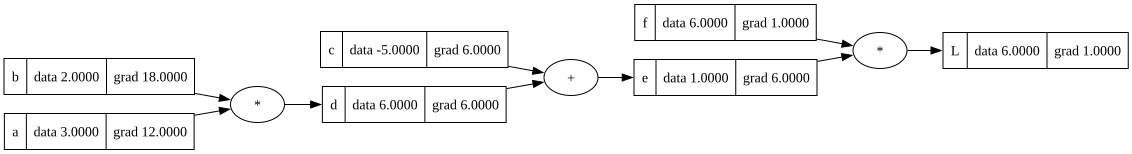

In [6]:
L.backward()

draw_dot(L)

Suppose to be doing some manual backpropagation here but can't be bothered as it's just super basic chain rule $\frac{dz}{dx} = \frac{dz}{dy} \frac{dy}{dx}$  
Note that here the '+' nodes kind of 'distribute' the derivatives to its child nodes

Below is an example that visualises what the computational graph for a very simple neuron might look like. 

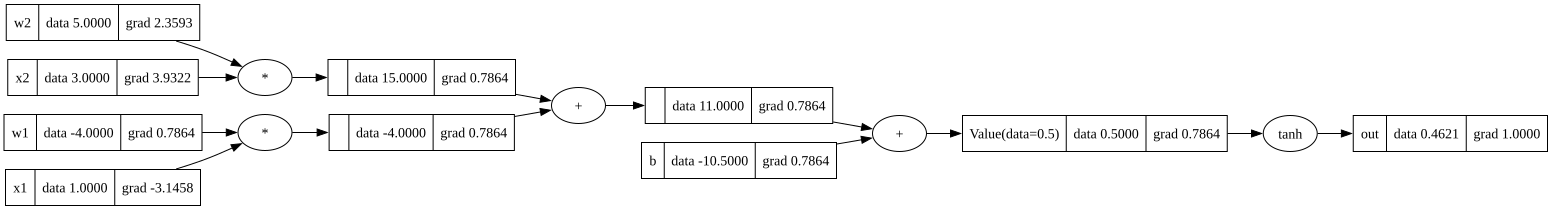

In [ ]:
# Inputs
x1 = Value(1.0, label='x1')
x2 = Value(3.0, label='x2')

# Weights
w1 = Value(-4.0, label = 'w1')
w2 = Value(5.0, label='w2')

# Bias of this neuron
b = Value(-10.5, label='b')
x1w1 = x1*w1
x2w2 = x2*w2
x1w1x2w2 = x1w1+x2w2
n = x1w1x2w2 + b
n.label = n
out = n.tanh()
out.label = 'out'

out.backward()

draw_dot(out)


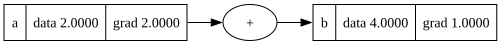

In [8]:
# Test case where one node is used multiple times

a = Value(2.0, label = 'a')
b = a + a
b.label = 'b'
b.backward()
draw_dot(b)

In [9]:
import torch

In [ ]:
# Checking if this primitive scalar autograd engine agrees with values outputted by PyTorch's autograd
# Here, I'm using pytorch tensors as scalars
# Inputs
x1 = torch.Tensor([1.0]).double()
x1.requires_grad = True
x2 = torch.Tensor([3.0]).double()
x2.requires_grad = True

# Weights
w1 = torch.Tensor([-4.0]).double()
w1.requires_grad = True
w2 = torch.Tensor([5.0]).double()
w2.requires_grad = True

# Bias of this neuron
b = torch.Tensor([-10.5]).double()
b.requires_grad = True

n = x1*w1 + x2*w2 + b

out = torch.tanh(n)

out.backward()
print(out.data.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())
print('x2', x2.grad.item())
print('w2', w2.grad.item())

0.46211715726000974
x1 -3.1457909318637096
w1 0.7864477329659274
x2 3.932238664829637
w2 2.359343198897782


In [55]:
# Building basic example of neural network using the scalar autograd engine above

class Neuron:
    def __init__(self, nin):
        # nin = Number of inputs, basically children of this node
        # Initialises all weights and the bias with random numbers between -1 and 1 (might be related to the activation function being tanh?)
        self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):
        activation = sum(wi*xi for wi, xi in zip(self.w, x)) + self.b
        out = activation.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

# x = [1.0, 2.0]
# n = Neuron(2)
# n(x)

$activation = \sum_i{x_i w_i} + b$

In [56]:
class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs
    
    # Collects all the parameters (i.e. weights and biases of the layer)
    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
    
# x = [1.0, 2.0]
# # Corresponds to a single layer of 3 neurons, each having two inputs. 
# n = Layer(2,3)
# n(x)

In [ ]:
# The actual layer by layer representation of a neural network (Multilayer perceptron)
class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts # Prepends 'nin' to the list
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))] # Constructs layers one by one, first parameter is the input number of neurons, second parameter is the output number of neurons

    def __call__(self, x):
        # This is the forward pass of the neural network
        # Overwrites the input with the outputs from each layer as the neural network passes from Input -> Layer 1 -> Layer 2 ->...
        for layer in self.layers:
            x = layer(x)
        return x
    
    # Collects all parameters over whole neural network
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [119]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [3, 4, 1])
n(x)

Value(data=0.9832563482972546)

$x = [2.0, 3.0, -1.0, 4,0]$  
$n = MLP(4, [5, 5, 4])$
The values from left to right passed into the class MLP describe how many neurons are in each layer. So, in this case there are 4 neurons in the input layer and 4 neurons in the output layer.  This code above would correspond to the following diagram. Note that the 'input layer' isn't really a layer, but a placeholder for the input data. 'Real' neurons only starts after the second layer.  
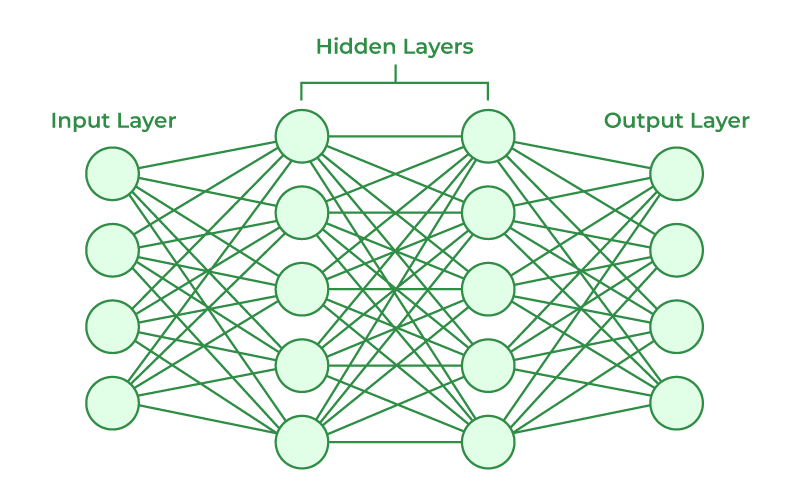

In [ ]:
# Gross visualisation of what even an extremely simple neural network looks like

final_node = sum(n(x))
draw_dot(final_node)

# Deleted cell output here as it's unnecessarily large

In [116]:
xs = [
[2.0, 3.0, -1.0],
[3.0, -1.0, 0.5],
[0.5, 1.0, 1.0], 
[1.0, 1.0, -1.0],
]

# Desired targets
ys = [1.0, -1.0, -1.0, 1.0]


In [113]:
ypred = [n(x) for x in xs]

# Loss function (Mean Squared Error)
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=0.19056895793592804)

In [111]:
loss.backward()

In [ ]:
len(n.parameters()) # Total amount of weights and biases

33

In [ ]:
# Gradient descent
# 0.01 here is the learning rate
for p in n.parameters():
    p.data += -0.01 * p.grad # We want to minimise the loss function

In [120]:
for k in range(20):
    # Forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    # Backward pass
    for p in n.parameters():
        p.grad = 0.0 # Zero-grad
    loss.backward()

    # Update
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k, loss.data)

0 4.829061759226045
1 0.7301106448794216
2 0.22338875224768434
3 0.14583659673009033
4 0.11123314548554948
5 0.09108086134774668
6 0.07762682876880873
7 0.0678714811895269
8 0.060403506009726944
9 0.05446613730394316
10 0.049613215773398625
11 0.045562167706447776
12 0.0421238321072682
13 0.039165937713556497
14 0.036592711032679484
15 0.03433281143365733
16 0.032331839300038676
17 0.030547490859579397
18 0.02894631496436638
19 0.02750147751869392


In [121]:
ypred

[Value(data=0.9701449934161593),
 Value(data=-0.9381491087198718),
 Value(data=-0.873009696722724),
 Value(data=0.9184029031032845)]